**This Code is to get Quadrupolar, CSA , and ACS, components from Central and Satellite Transitions**

*Shiva Agarwal (26 March 2024)*

In [30]:
from libraries import*
from simulation_B_spin_modified import  wX, Ispin, w0, delta_ppm, eta, CQ_M, Qeta, alpha, beta, gamma, QPAS, Siso_ppm, Siso, QXG, CsaQXG, AcsQXG
from functions import fourier3, fourier5, Rabc, Quad, ChemShift

**Read Data**

In [2]:
titles = ['x rotation', 'y rotation', 'z rotation']
df = [0]*len(titles)
set = 1             #which set to analyse
file_path = ('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_simulation/')

for i, orientation in enumerate(titles):
    file_name = f'{orientation}_set{set}_B.csv'
    df[i] = pd.read_csv(file_path+file_name, index_col=0)
    

# print(df[0])

**Plot Raw data**

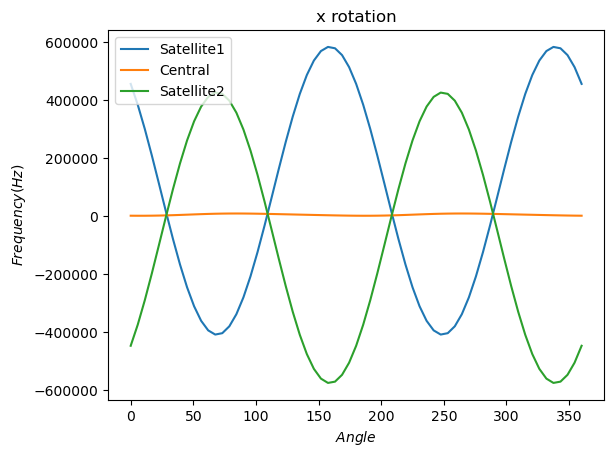

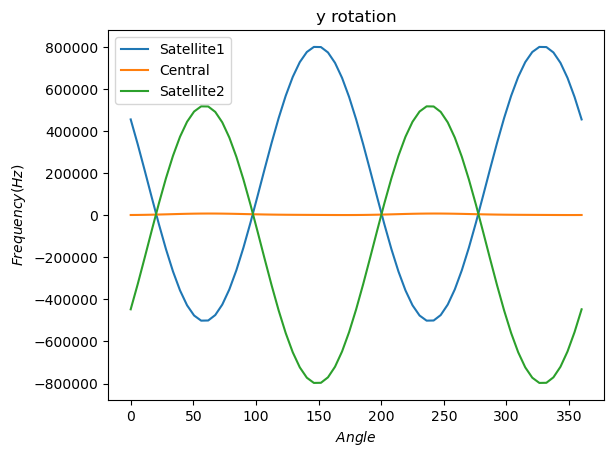

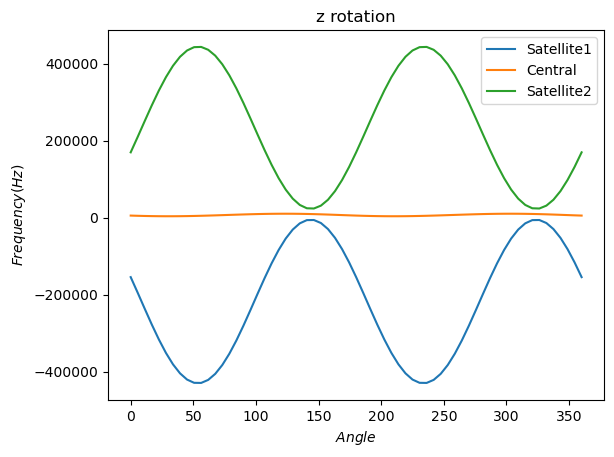

In [3]:
for i in range (3):
    plt.plot(df[i].angle, df[i].freq_3212, label = 'Satellite1')
    plt.plot(df[i].angle, df[i].freq_1212, label = 'Central')
    plt.plot(df[i].angle, df[i].freq_1232, label = 'Satellite2')
    plt.title(titles[i])
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    plt.legend()
    plt.show()

**Find H_Q(2) Tensor Components**

In [4]:
df_Q = [0]*3
for i in range(len(titles)):
    df_Q[i] =  -2*df[i].freq_1212 + df[i].freq_1232 + df[i].freq_3212 #from equation in Rotating Frame hamiltonian_32_52 word document
            

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.55e-17 (chi2/ndof = 0.0) │              Nfcn = 143              │
│ EDM = 1.12e-22 (Goal: 0.0002)    │            time = 0.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─────────────┴────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──────

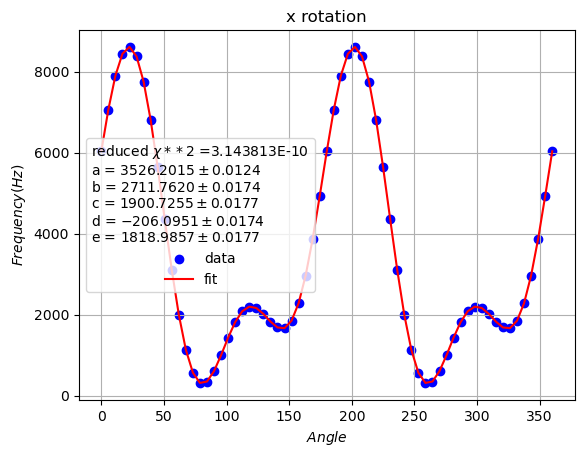

a = 3526.2015236528946
b = 2711.7619898527983
c = 1900.7255216027677
d = -206.0950678419326
e = 1818.9857261178977
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.921e-17 (chi2/ndof = 0.0)│              Nfcn = 139              │
│ EDM = 2.84e-22 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─

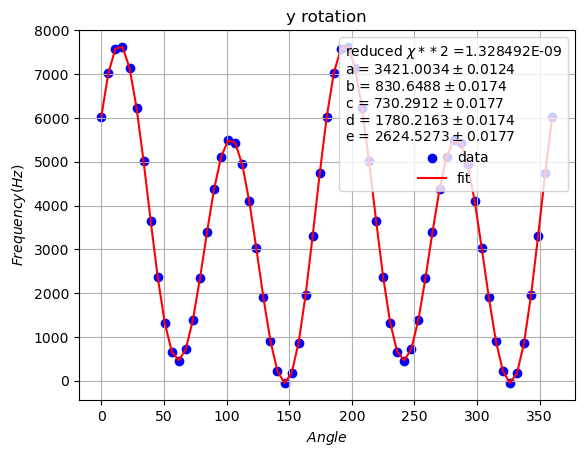

a = 3421.003365541886
b = 830.6487588456171
c = 730.2911603823691
d = 1780.2163212762168
e = 2624.527322915479
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.319e-17 (chi2/ndof = 0.0)│              Nfcn = 149              │
│ EDM = 9.81e-23 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─────

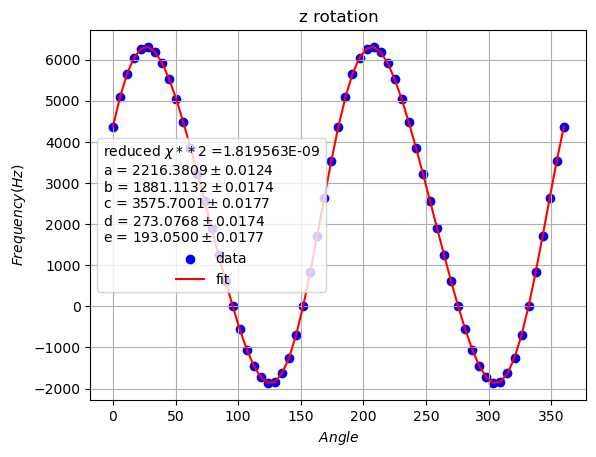

a = 2216.3809445335078
b = 1881.1132310071494
c = 3575.7001262925764
d = 273.0767524318168
e = 193.05001842359516


In [5]:
m_Q = [0]*3

for i in range(3):
    least_squares = LeastSquares(df[i].angle, df_Q[i], 0.1,fourier5)
    
    m_Q[i] = Minuit(least_squares, a = 1, b = 1, c= 1, d = 0, e = 1).migrad()
    # m[i] = m[i].scan(ncall = 50)

    # m[i].migrad()  # finds minimum of least_squares function
    m_Q[i].hesse()   # accurately computes uncertainties
    
    fit_info = [
        f"reduced $\\chi**2$ ={(m_Q[i].fval / (len(df[i].angle) - m_Q[i].nfit)):5E}"
    ]
    # print(fit_info)
    
    for p, v, e in zip(m_Q[i].parameters, m_Q[i].values, m_Q[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    print(m_Q[i].migrad())
    # plt.imshow(corr_mat, cmap='coolwarm')
    
    # draw data and fitted line
    plt.scatter(df[i].angle, df_Q[i], label="data", color = 'blue')
    plt.plot(df[i].angle, fourier5(df[i].angle, *m_Q[i].values), label="fit", color = 'red')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # plt.title(titles[i] +'\n'r'$Fitting\ of\ H^1_{CSA} = A + B(cos2\theta )+ C(sin2\theta)$')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    plt.grid()
    plt.show()
    
    for key, value in zip(m_Q[i].parameters, m_Q[i].values):
        print(f"{key} = {value}")

In [15]:
a_Q = [0]*3; 
b_Q = [0]*3; 
c_Q = [0]*3; 
d_Q = [0]*3
e_Q = [0]*3

par_Q = [a_Q, b_Q, c_Q, d_Q, e_Q]
for i in range(0,3):
    for k in range(len(par_Q)):
        par_Q[k][i] = m_Q[i].values[k]

Dx = d_Q[0]*wX*72;
Ex = e_Q[0]*wX*72;

Dy = d_Q[1]*wX*72;
Ey = e_Q[1]*wX*72;

Dz = d_Q[2]*wX*72;
Ez = e_Q[2]*wX*72;

#solving equations for Isolation of 2nd order Uadrupolar Interaction
gyz2 = (Dx + np.sqrt(Dx**2+Ex**2))/(2*102/4);
gyz_q = -np.sqrt(gyz2); 
gzzmgyy = (4*Ex/102)*(1/gyz_q);

# print(Dx)

gxz2 = (Dy + np.sqrt(Dy**2+Ey**2))/(2*102/4);
gxz_q = np.sqrt(gxz2);
gzzmgxx = -(4*Ey/102)*(1/gxz_q);

# print(Gxz_Q)

gxy2 = (Dz + np.sqrt(Dz**2+Ez**2))/(2*102/4);
gxy_q = -np.sqrt(gxy2);
gxxmgyy = (4*Ez/102)*(1/gxy_q);

# print(Gxy_Q)

gzz1 = (gzzmgyy + gzzmgxx)/3
gyy1 = gzz1 -gzzmgyy
gxx1 = gzz1 -gzzmgxx

gxx2 = (gxxmgyy-gzzmgxx)/3
gzz2 = gxx2+gzzmgxx
gyy2 = gxx2-gxxmgyy

gyy3 = -(gzzmgyy + gxxmgyy)/3
gzz3 = gyy3 + gzzmgyy
gxx3 = gyy3 + gxxmgyy

gxx_q = (gxx1+gxx2+gxx3)/3;
gyy_q = (gyy1+gyy2+gyy3)/3;
gzz_q = (gzz1+gzz2+gzz3)/3;

# print(Gxx, Gyy, Gzz)

QXG_f = np.zeros((3, 3))                                #Fit tensor
QXG_f[0,0]=gxx_q; QXG_f[0,1]=gxy_q; QXG_f[0,2]=gxz_q;
QXG_f[1,0]=gxy_q; QXG_f[1,1]=gyy_q; QXG_f[1,2]=gyz_q;
QXG_f[2,0]=gxz_q; QXG_f[2,1]=gyz_q; QXG_f[2,2]=gzz_q;

QXG_f = -QXG_f;


# print(Gzz1, Gzz2, Gzz3)
print('Input Quadrupolar Tensor:\n', QXG)
print('Calculated Quad Tensor:\n',QXG_f)

Input Quadrupolar Tensor:
 [[ -323869.84817682   406374.29633229 -1160174.20545491]
 [  406374.29633229  -582143.11502086   664533.14553804]
 [-1160174.20545491   664533.14553804   906012.96319768]]
Calculated Quad Tensor:
 [[ -323869.84817682   406374.29633229 -1160174.20545491]
 [  406374.29633229  -582143.11502086   664533.14553804]
 [-1160174.20545491   664533.14553804   906012.96319768]]


**Find HQ1 and HQ2 Tensor Components**

In [13]:
HQ1_freq_3212 = [0]*3
HQ1_freq_1212 = [0]*3
HQ1_freq_1232 = [0]*3


HQ2_freq_3212 = [0]*3
HQ2_freq_1212 = [0]*3
HQ2_freq_1232 = [0]*3

for i in range (3):
    ang = df[i].angle*np.pi/180.
    atheta = [-ang, ang,np.pi/2 ] #-x, y, -z rotation
    aphi = [np.pi/2, 0, -ang]

    theta = atheta[i] 
    phi = aphi[i]
    ct = np.cos(theta); st = np.sin(theta); s2t = 2*ct*st; c2t = ct*ct-st*st;
    cp = np.cos(phi); sp = np.sin(phi); s2p = 2*cp*sp; c2p = cp*cp-sp*sp;

    R2m2Q, R2m1Q, R20Q, R2p1Q, R2p2Q = Quad(QXG_f,ct, st, s2t, c2t, cp ,sp ,c2p ,s2p)

            
    HQ1 = 1/(2*Ispin*(2*Ispin-1))*R20Q
    HQ2a= (0.5/(2*Ispin*(2*Ispin-1))**2)*(R2m2Q*R2p2Q)/wX                         
    HQ2b = (0.5/(2*Ispin*(2*Ispin-1))**2)*(R2m1Q*R2p1Q)/wX


    HQ1_freq_3212[i] = 6*(np.real(HQ1))               # 3/2 <-> 1/2
    HQ1_freq_1212[i] = 0*(np.real(HQ1))               # 1/2 <-> -1/2
    HQ1_freq_1232[i] = -6*(np.real(HQ1))              #-1/2   <-> -3/2       
    
    HQ2_freq_3212[i] = 0*np.real(HQ2a) + -12*np.real(HQ2b)       # 3/2 <-> 1/2
    HQ2_freq_1212[i] = 6*np.real(HQ2a) + 12*np.real(HQ2b)        # 1/2 <-> -1/2
    HQ2_freq_1232[i] = 0*np.real(HQ2a) + -12*np.real(HQ2b)       #-1/2   <-> -3/2  

**Find HCSA1**

┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │         1   -0.0216  6.36e-12 │
│ b │   -0.0216         1 -2.94e-10 │
│ c │  6.36e-12 -2.94e-10         1 │
└───┴───────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.3e-19 (chi2/ndof = 0.0)  │              Nfcn = 95               │
│ EDM = 1.11e-23 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬──

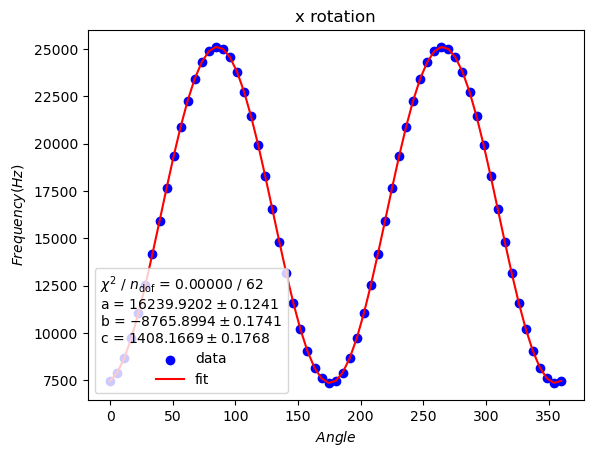

a = 16239.920245582354
b = -8765.89944414674
c = 1408.1669151992153
┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │         1   -0.0216 -2.95e-12 │
│ b │   -0.0216         1 -1.29e-10 │
│ c │ -2.95e-12 -1.29e-10         1 │
└───┴───────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.858e-19 (chi2/ndof = 0.0)│              Nfcn = 93               │
│ EDM = 6.15e-23 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call 

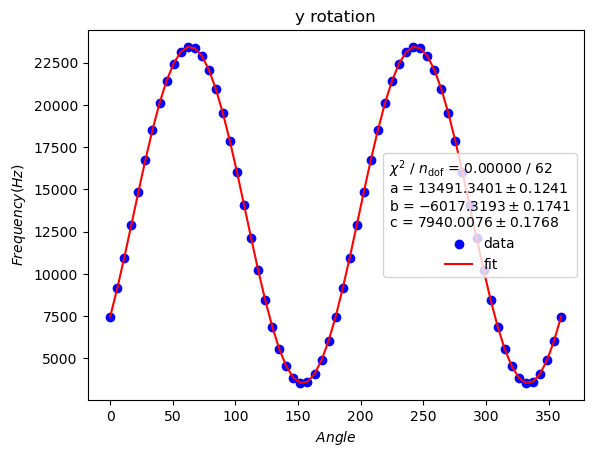

a = 13491.340155135471
b = -6017.3193536998815
c = 7940.007620310242
┌───┬───────────────────────────────┐
│   │         a         b         c │
├───┼───────────────────────────────┤
│ a │         1   -0.0216  3.74e-11 │
│ b │   -0.0216         1 -3.14e-10 │
│ c │  3.74e-11 -3.14e-10         1 │
└───┴───────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 7.896e-20 (chi2/ndof = 0.0)│              Nfcn = 88               │
│ EDM = 1.82e-23 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call

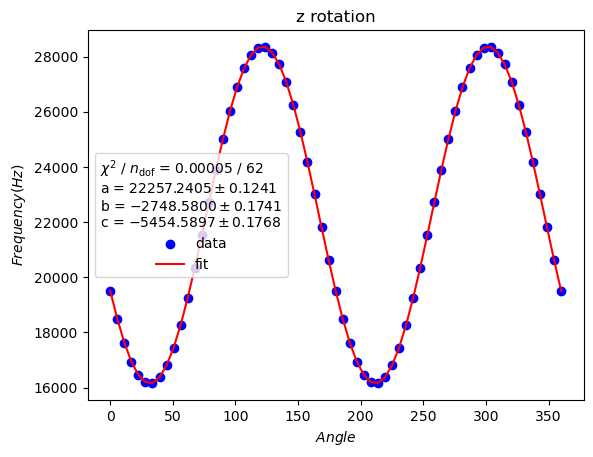

a = 22257.23959928221
b = -2748.580090446889
c = -5454.58972354943


In [14]:
HQ2_freq_sum = [0]*3
csa = [0]*3
m_csa = [0]*3

for i in range(3):
    HQ2_freq_sum[i] = HQ2_freq_3212[i] + HQ2_freq_1212[i] + HQ2_freq_1232[i]
    csa[i] = df[i].freq_sum - HQ2_freq_sum[i]  
    least_squares = LeastSquares(df[i].angle, csa[i], 1,fourier3)
    
    m_csa[i] = Minuit(least_squares, a = -1, b = -1, c= -1)
    # m[i] = m[i].scan(ncall = 50)

    m_csa[i].migrad()  # finds minimum of least_squares function
    m_csa[i].hesse()   # accurately computes uncertainties
    fit_info = [
        f"$\\chi^2$ / $n_\\mathrm{{dof}}$ = {m_csa[i].fval:.5f} / {len(df[i].angle) - m_csa[i].nfit}",
    ]
    # print(fit_info)
    

    for p, v, e in zip(m_csa[i].parameters, m_csa[i].values, m_csa[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    corr_mat = (m_csa[i].covariance.correlation())
    print(corr_mat)
    print(m_csa[i].migrad())
    # plt.imshow(corr_mat, cmap='coolwarm')
    
    # draw data and fitted line
    plt.scatter(df[i].angle, csa[i], label="data", color = 'blue')
    plt.plot(df[i].angle, fourier3(df[i].angle, *m_csa[i].values), label="fit", color = 'red')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # plt.title(titles[i] +'\n'r'$Fitting\ of\ H^1_{CSA} = A + B(cos2\theta )+ C(sin2\theta)$')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    # plt.grid()
    plt.show()
    
    for key, value in zip(m_csa[i].parameters, m_csa[i].values):
        print(f"{key} = {value}")

a_csa = [0]*3; 
b_csa = [0]*3; 
c_csa = [0]*3; 

par_csa = [a_csa, b_csa, c_csa]

for i in range(0,3):
    for k in range(len(par_csa)):
        par_csa[k][i] = m_csa[i].values[k]


In [16]:
A= [0]*3
B = [0]*3
C = [0]*3
A_HCSA1 = [0]*3
B_HCSA1 = [0]*3
X = [0]*3


for i in range(0,3):

    A_HCSA1[i] = np.array([[3/2, 3/2], [3/2, -3/2]])
    B_HCSA1[i] = np.array([a_csa[i], b_csa[i]])
    X[i] = np.linalg.inv(A_HCSA1[i]).dot(B_HCSA1[i])
    

gzz_csa1 = X[0][0]
gyy_csa1= X[0][1]
gyz_csa = -c_csa[0]/3

gzz_csa2 = X[1][0]
gxx_csa2 = X[1][1]
gxz_csa = c_csa[1]/3

gxx_csa3 = X[2][0]
gyy_csa3 = X[2][1]
gxy_csa = -c_csa[2]/3

gxx_csa = np.mean([gxx_csa2, gxx_csa3])
gyy_csa = np.mean([gyy_csa1, gyy_csa3])
gzz_csa = np.mean([gzz_csa1, gzz_csa2])




CsaQXG_f = np.zeros((3, 3))                                #Tensor from fitting
CsaQXG_f[0,0]=gxx_csa; CsaQXG_f[0,1]=gxy_csa; CsaQXG_f[0,2]=gxz_csa;
CsaQXG_f[1,0]=gxy_csa; CsaQXG_f[1,1]=gyy_csa; CsaQXG_f[1,2]=gyz_csa;
CsaQXG_f[2,0]=gxz_csa; CsaQXG_f[2,1]=gyz_csa; CsaQXG_f[2,2]=gzz_csa;


print('Input CSA Tensor:\n', CsaQXG)
print('Calculated CSA Tensor:\n',CsaQXG_f)


print(tabulate([['gxx_q',gxx_q], ['gyy_q',gyy_q], ['gzz_q',gzz_q], ['gxy_q',gxy_q], ['gyz_q',gyz_q], ['gxz_q',gxz_q],['gxx_csa',gxx_csa], ['gyy_csa',gyy_csa], ['gzz_csa',gzz_csa], ['gxy_csa',gxy_csa], ['gyz_csa',gyz_csa], ['gxz_csa',gxz_csa]]))

Input CSA Tensor:
 [[6502.88650295 1818.19657452 2646.66920677]
 [1818.19657452 8335.27322991 -469.38897173]
 [2646.66920677 -469.38897173 2491.34026715]]
Calculated CSA Tensor:
 [[6502.88650295 1818.19657452 2646.66920677]
 [1818.19657452 8335.27322991 -469.38897173]
 [2646.66920677 -469.38897173 2491.34026715]]
-------  -----------------
gxx_q     323870
gyy_q     582143
gzz_q    -906013
gxy_q    -406374
gyz_q    -664533
gxz_q          1.16017e+06
gxx_csa     6502.89
gyy_csa     8335.27
gzz_csa     2491.34
gxy_csa     1818.2
gyz_csa     -469.389
gxz_csa     2646.67
-------  -----------------


**Fit Values**

In [17]:
#****** Input Vaue****************

#for CSA
Siso_fit = (gxx_csa + gyy_csa + gzz_csa)/3
Siso_ppm_fit = Siso_fit/w0
delta_fit = gzz_csa/w0 - Siso_ppm_fit
eta_fit = (gxx_csa - gyy_csa)/w0/delta_fit

#for Quadrupolar
CQ_fit = gzz_q*(2*Ispin*(2*Ispin - 1))/10**6
Qeta_fit = (gxx_q - gyy_q)/gzz_q

table = [['Siso',Siso_ppm_fit, Siso_ppm, abs(Siso_ppm_fit - Siso_ppm)*100/Siso_ppm, ],['delta', delta_fit, delta_ppm, abs(delta_fit - delta_ppm)*100/delta_ppm],  ['eta', eta_fit, eta, abs(eta_fit - eta)*100/eta],  ['CQ', CQ_fit, CQ_M, abs((CQ_fit - CQ_M)/CQ_M)*100], ['Qeta', Qeta_fit ,Qeta, abs(Qeta_fit - Qeta)*100/Qeta]]
print(tabulate(table, headers=['Qauntity', 'Fit Value','Input Value', '% difference']))

Qauntity      Fit Value    Input Value    % difference
----------  -----------  -------------  --------------
Siso          30                 30        3.55271e-14
delta        -17.0613           -25      -31.7547
eta            0.557777          -0.6   -192.963
CQ            -5.43608           10      154.361
Qeta           0.285066           0.85    66.4629


**Find HCSA1 and HQ,CSA**

In [20]:
HCSA1_freq_3212 = [0]*3
HCSA1_freq_1212 = [0]*3
HCSA1_freq_1232 = [0]*3


HQCSA_freq_3212 = [0]*3
HQCSA_freq_1212 = [0]*3
HQCSA_freq_1232 = [0]*3

for i in range (3):
    ang = df[i].angle*np.pi/180.
    atheta = [-ang, ang,np.pi/2 ] #-x, y, -z rotation
    aphi = [np.pi/2, 0, -ang]

    theta = atheta[i] 
    phi = aphi[i]
    ct = np.cos(theta); st = np.sin(theta); s2t = 2*ct*st; c2t = ct*ct-st*st;
    cp = np.cos(phi); sp = np.sin(phi); s2p = 2*cp*sp; c2p = cp*cp-sp*sp;

    R2m2Q, R2m1Q, R20Q, R2p1Q, R2p2Q = Quad(QXG_f,ct, st, s2t, c2t, cp ,sp ,c2p ,s2p)
    R2m1cs, R20cs, R2p1cs = ChemShift(CsaQXG_f,ct, st, s2t, c2t, cp, sp, c2p, s2p)
    

            
    HCSA1 = (R20cs + 1/3*(CsaQXG_f[2, 2] + CsaQXG_f[0,0] + CsaQXG_f[1,1]))                       # Siso = 1/3*(CsaQXG[2, 2] + CsaQXG[0,0] + CsaQXG[1,1]); Siso added to CSA tensor
    HQCSA = -(0.5/(2*Ispin*(2*Ispin-1)))*(R2m1Q*R2p1cs+R2p1Q*R2m1cs)/wX;


    HCSA1_freq_3212[i] = 1*np.real(HCSA1)               # 3/2 <-> 1/2
    HCSA1_freq_1212[i] = 1*np.real(HCSA1)               # 1/2 <-> -1/2
    HCSA1_freq_1232[i] = 1*np.real(HCSA1)             #-1/2   <-> -3/2       
    
    HQCSA_freq_3212[i] = 6*(np.real(HQCSA))       # 3/2 <-> 1/2
    HQCSA_freq_1212[i] = 0*(np.real(HQCSA))       # 1/2 <-> -1/2
    HQCSA_freq_1232[i] = -6*(np.real(HQCSA))      #-1/2   <-> -3/2   

**Fit HQ_ACS**

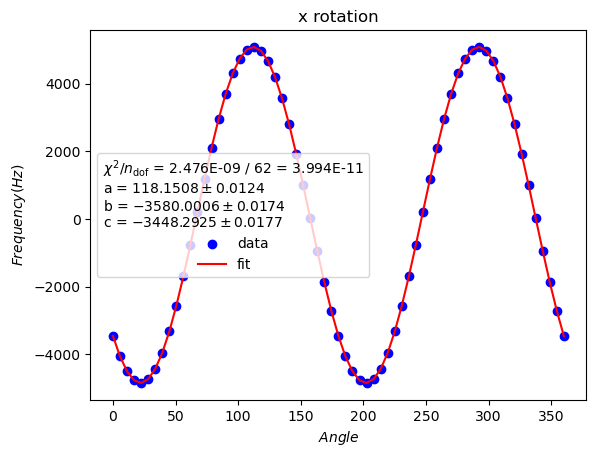

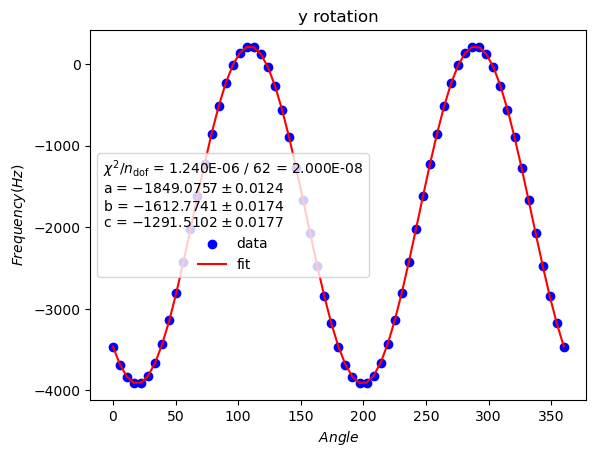

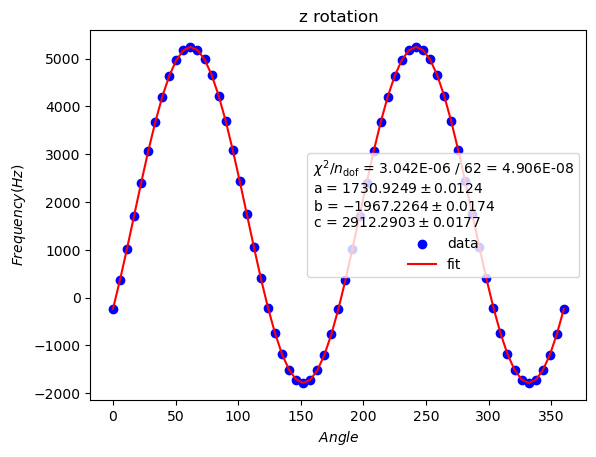

In [23]:
HACS_freq_3212 = [0]*3
HACS_freq_1212 = [0]*3
HACS_freq_1232 = [0]*3

acs = [0]*3
m_acs = [0]*3

for i in range (3):
    HACS_freq_3212[i] = df[i].freq_3212 - (HQ1_freq_3212[i] + HQ2_freq_3212[i] + HCSA1_freq_3212[i] + HQCSA_freq_3212[i])
    HACS_freq_1212[i] = df[i].freq_1212 - (HQ1_freq_1212[i] + HQ2_freq_1212[i] + HCSA1_freq_1212[i] + HQCSA_freq_1212[i])
    HACS_freq_1232[i] = df[i].freq_1232 - (HQ1_freq_1232[i] + HQ2_freq_1232[i] + HCSA1_freq_1232[i] + HQCSA_freq_1232[i])

    acs[i] = HACS_freq_3212[i] - HACS_freq_1232[i] 

    least_squares = LeastSquares(df[i].angle, acs[i], 0.1,fourier3)

    #***********************Trying to fit input ACS ****************
    # least_squares = LeastSquares(df[i].angle, df[i].acs, 0.1,fourier3)

    m_acs[i] = Minuit(least_squares, a = 1000, b = 100, c= 100)
    # m_acs[i].fixed["c"] = True
    # # m_d[i].fixed["b"] = True
    # # m[i] = m[i].scan(ncall = 50)

    m_acs[i].migrad()  # finds minimum of least_squares function
    m_acs[i].hesse()   # accurately computes uncertainties
    fit_info = [
        f"$\\chi^2$/$n_\\mathrm{{dof}}$ = {m_acs[i].fval:.3E} / {m_acs[i].ndof:.0f} = {m_acs[i].fmin.reduced_chi2:.3E}",
    ]
    
    

    for p, v, e in zip(m_acs[i].parameters, m_acs[i].values, m_acs[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    # corr_mat = (m_acs[i].covariance.correlation())
    # # print(corr_mat)
    # # print(m_d[i].migrad())
    # # plt.imshow(corr_mat, cmap='coolwarm')
    
    # draw data and fitted line
    plt.scatter(df[i].angle, acs[i], label="data", color = 'blue')
    plt.plot(df[i].angle, fourier3(df[i].angle, *m_acs[i].values), label="fit", color = 'red')
    # plt.plot(df[i].angle, df[i].acs, label = "input data")
    # plt.plot(xdata, HQ1[i], label = 'input ')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # # plt.title(titles[i] +'\n'r'$Fitting\ of\ H^1_{CSA} = A + B(cos2\theta )+ C(sin2\theta)$')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    # plt.grid()
    plt.show()

In [25]:
a_acs = [0]*3; 
b_acs = [0]*3; 
c_acs = [0]*3; 

par_acs = [a_acs, b_acs, c_acs]

for i in range(0,3):
    for k in range(len(par_acs)):
        par_acs[k][i] = m_acs[i].values[k]

In [27]:
#-X rotation
gxy_acs1, gxz_acs1, gyz_acs1 = sym.symbols('gxy_acs1, gxz_acs1, gyz_acs1')


eq1 = sym.Eq(gxy_q*gxy_acs1 + gxz_q*gxz_acs1, a_acs[0]*(-wX*2/3))
eq2 = sym.Eq(gxy_q*gxy_acs1 - gxz_q*gxz_acs1 - 2*gyz_q*gyz_acs1, b_acs[0]*(wX*2/3))
eq3 = sym.Eq((gyy_q - gzz_q)*gyz_acs1 + gxy_q*gxz_acs1 + gxz_q*gxy_acs1, c_acs[0]*(wX*2/3))
result1 = sym.solve([eq1, eq2, eq3], (gxy_acs1, gxz_acs1, gyz_acs1))

print(result1)

{gxy_acs1: 43356.2951402053, gxz_acs1: 2113.70170229455, gyz_acs1: -330669.429276482}


In [28]:
#Y rotation
gxy_acs2, gxz_acs2, gyz_acs2 = sym.symbols('gxy_acs2, gxz_acs2, gyz_acs2')


eq1 = sym.Eq(gxy_q*gxy_acs2 - gyz_q*gyz_acs2, a_acs[1]*(wX*2/3))
eq2 = sym.Eq( 2*gxz_q*gxz_acs2 - gxy_q*gxy_acs2 - gyz_q*gyz_acs2 , b_acs[1]*(wX*2/3))
eq3 = sym.Eq(-(gzz_q - gxx_q)*gxz_acs2 + gyz_q*gxy_acs2 - gxy_q*gyz_acs2, c_acs[1]*(wX*2/3))
result2 = sym.solve([eq1, eq2, eq3], (gxy_acs2, gxz_acs2, gyz_acs2))

print(result2)

{gxy_acs2: 43356.2962657346, gxz_acs2: -2113.70228373643, gyz_acs2: -330669.426270984}


In [29]:
#-Z rotation
gxy_acs3, gxz_acs3, gyz_acs3 = sym.symbols('gxy_acs3, gxz_acs3, gyz_acs3')


eq1 = sym.Eq(gxz_q*gxz_acs3 + gyz_q*gyz_acs3, a_acs[2]*(-wX*2/3))
eq2 = sym.Eq( -2*gxy_q*gxy_acs3 - gxz_q*gxz_acs3 + gyz_q*gyz_acs3 , b_acs[2]*(wX*2/3))
eq3 = sym.Eq((gyy_q - gxx_q)*gxy_acs3 + gxz_q*gyz_acs3 + gyz_q*gxz_acs3, c_acs[2]*(wX*2/3))
result3 = sym.solve([eq1, eq2, eq3], (gxy_acs3, gxz_acs3, gyz_acs3))

print(result3)

{gxy_acs3: -43356.2999335121, gxz_acs3: -2113.70497659627, gyz_acs3: 330669.427446492}


In [31]:
# dictionryList = [result1, result2, result3]
# new = {}
gxy_acs = np.mean([result1[gxy_acs1], result2[gxy_acs2], result3[gxy_acs3]])
gxz_acs = np.mean([result1[gxz_acs1], result2[gxz_acs2], result3[gxz_acs3]])
gyz_acs = np.mean([result1[gyz_acs1], result2[gyz_acs2], result3[gyz_acs3]])

# print(gxy_acs, gxz_acs, gyz_acs)

AcsQXG_f = np.zeros((3, 3))                                #Tensor from fitting
AcsQXG_f[0,1]=gxy_acs; AcsQXG_f[0,2]=gxz_acs;
AcsQXG_f[1,0]=-gxy_acs;  AcsQXG_f[1,2]=gyz_acs;
AcsQXG_f[2,0]=-gxz_acs; AcsQXG_f[2,1]=-gyz_acs; 


print('Input Quadrupolar Tensor:\n', AcsQXG)
print('Calculated Quad Tensor:\n',AcsQXG_f)

Input Quadrupolar Tensor:
 [[ 8.86945985e-12  6.50344427e+04  3.17055265e+03]
 [-6.50344427e+04 -1.38794976e-11 -4.96004144e+05]
 [-3.17055265e+03  4.96004144e+05  1.14812390e-11]]
Calculated Quad Tensor:
 [[      0.           14452.09715748    -704.56851935]
 [ -14452.09715748       0.         -110223.14270032]
 [    704.56851935  110223.14270032       0.        ]]
